In [1]:
import pandas as pd
import numpy as np
import openpyxl as px

In [2]:
pd.set_option('display.max_rows', None)   # Show all rows
pd.set_option('display.max_columns', None)  # Show all columns
pd.set_option('display.max_colwidth', None)  # Show full column content
pd.set_option('display.width', None)  # Don’t wrap columns

In [3]:
df = pd.read_excel("Baseline_Brazil_a.xlsx", sheet_name="Plan1")
df = df.drop(columns=['pregnant', 'job', 'curso', 'geral_id', 
                      'year_entered', 'bmi', 'year',
                      'score_food_smile', 'score_subs_smile', 'score_PA_smile', 
                      'score_stress_smile', 'score_sleep_smile', 'score_social_smile', 
                      'score_envir_smile', 'scoretot_smile'])

courses = pd.read_excel("Untitled 1.ods", engine='odf')
df = pd.concat([df, courses], axis=1)

drop = [1, 2, 3]
df = df[~df['student_of'].isin(drop)]
df = df.drop(columns=['student_of'])

print(f"{df.shape[0]} rows, {df.shape[1]} columns")

CATEGORICAL_MAX_UNIQUE = 6

def is_integer_valued(series):
    non_null = series.dropna()
    if len(non_null) == 0:
        return False
    return np.issubdtype(non_null.dtype, np.floating) and (non_null == non_null.round()).all()

categorical_cols = []
numerical_cols   = []

for col in df.columns:
    s = df[col]
    if is_integer_valued(s) and s.nunique() <= CATEGORICAL_MAX_UNIQUE:
        categorical_cols.append(col)
    else:
        numerical_cols.append(col)

df['gad7_class'] = df['gad7_class'] + 1

print("Categorical columns:", categorical_cols)
print("Numerical columns  :", numerical_cols)

sexual_dicotomico_indexes = df[df['sexual_orientation'] == 0].index.tolist()
gender_dicotomico_indexes = df[df['gender_identity'] == 0].index.tolist()

df.describe()


6398 rows, 40 columns
Categorical columns: ['sex', 'gender_identity', 'sexual_orientation', 'ethnic_group', 'bmi_class', 'marital_status', 'student_accommodation', 'work', 'smile_2', 'smile_3', 'smile_5', 'smile_8', 'smile_9', 'smile_10', 'smile_11', 'smile_12', 'smile_13', 'smile_15', 'smile_17', 'smile_19', 'smile_25', 'smile_27', 'smile_28', 'smile_30', 'smile_31', 'smile_32', 'smile_34', 'smile_37', 'smile_40', 'smile_41', 'smile_42', 'smile_43', 'sedentary_behavior', 'sedentary_2', 'gad7_class']
Numerical columns  : ['age', 'income', 'university', 'gad7_score', 'course']


,age,sex,gender_identity,sexual_orientation,ethnic_group,bmi_class,marital_status,student_accommodation,work,income,university,smile_2,smile_3,smile_5,smile_8,smile_9,smile_10,smile_11,smile_12,smile_13,smile_15,smile_17,smile_19,smile_25,smile_27,smile_28,smile_30,smile_31,smile_32,smile_34,smile_37,smile_40,smile_41,smile_42,smile_43,sedentary_behavior,sedentary_2,gad7_score,gad7_class,course
count,6398.000000,6385.000000,6326.000000,6357.000000,6373.000000,6197.000000,6380.000000,6386.000000,6374.000000,5.827000e+03,6398.000000,6391.000000,6385.000000,6393.00000,6373.000000,6381.000000,6381.000000,6367.000000,6382.000000,6387.000000,6349.000000,6380.000000,6379.000000,6392.000000,6372.000000,6394.000000,6385.000000,6379.000000,6388.000000,6382.000000,6383.000000,6385.000000,6384.000000,6389.000000,6386.000000,6316.000000,6318.000000,5243.000000,5709.000000,6398.000000
mean,19.934511,0.396398,0.063231,0.697656,0.924212,0.264483,1.065517,0.981209,0.810323,1.030502e+04,6.727884,0.800970,1.679875,2.08306,2.421309,2.776211,2.810375,2.977540,1.539799,0.686238,1.981729,0.713950,1.311491,1.611859,1.252511,1.198780,2.391699,1.844960,1.961490,1.914134,2.246436,0.889272,0.449561,1.398341,1.766990,2.162445,1.044634,10.601373,0.497635,3.310566
std,3.214580,0.489187,0.338027,1.073956,0.980858,0.760075,0.507139,0.135797,0.392076,2.873748e+05,3.624238,0.920369,0.685472,0.76440,0.761992,0.606189,0.547229,0.181534,1.060126,0.959338,1.082882,0.958208,1.182478,0.837064,0.859153,0.897391,0.721076,0.895239,1.026083,0.953959,0.783662,0.914133,0.683018,0.817316,1.017104,1.011050,1.083020,5.484620,0.500038,2.280197
min,16.000000,0.000000,0.000000,0.000000,0.000000,-1.000000,0.000000,0.000000,0.000000,0.000000e+00,1.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,18.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.500000e+03,3.000000,0.000000,1.000000,2.00000,2.000000,3.000000,3.000000,3.000000,1.000000,0.000000,1.000000,0.000000,0.000000,1.000000,1.000000,1.000000,2.000000,1.000000,1.000000,1.000000,2.000000,0.000000,0.000000,1.000000,1.000000,1.000000,0.000000,6.000000,0.000000,1.000000
50%,19.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,1.000000,1.000000,2.800000e+03,7.000000,1.000000,2.000000,2.00000,3.000000,3.000000,3.000000,3.000000,1.000000,0.000000,2.000000,0.000000,1.000000,2.000000,1.000000,1.000000,3.000000,2.000000,2.000000,2.000000,2.000000,1.000000,0.000000,1.000000,2.000000,2.000000,1.000000,10.000000,0.000000,3.000000
75%,20.000000,1.000000,0.000000,2.000000,2.000000,1.000000,1.000000,1.000000,1.000000,5.010500e+03,10.000000,1.000000,2.000000,3.00000,3.000000,3.000000,3.000000,3.000000,3.000000,1.000000,3.000000,1.000000,3.000000,2.000000,2.000000,2.000000,3.000000,3.000000,3.000000,3.000000,3.000000,2.000000,1.000000,2.000000,3.000000,3.000000,2.000000,15.000000,1.000000,5.000000
max,42.000000,1.000000,2.000000,4.000000,5.000000,2.000000,4.000000,1.000000,1.000000,2.000000e+07,13.000000,3.000000,3.000000,3.00000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,4.000000,4.000000,21.000000,1.000000,8.000000


In [4]:

# ── Regional grouping by university code ──────────────────────────────────────
# Codes 0–4 (alphabetical): 0=center-west, 1=north, 2=northeast, 3=south, 4=southeast
REGION_NAMES = ['center-west', 'north', 'northeast', 'south', 'southeast']

region_map = {
    1: 4, 12: 4, 13: 4,                   # southeast
    2: 2,  4: 2,  5: 2, 6: 2, 7: 2, 8: 2, # northeast
    3: 1,                                   # north
    11: 0,                                  # center-west
    9: 3, 10: 3,                            # south
}

df['region'] = df['university'].map(region_map).astype(int)

# Store original-df indexes per region code (used in cell 8 for per-region evaluation)
region_indexes = {
    code: df.index[df['region'] == code].tolist()
    for code in range(len(REGION_NAMES))
}

# Sanity check
print("Participants per region:")
for code, name in enumerate(REGION_NAMES):
    print(f"  {code} = {name}: {len(region_indexes[code])}")

print("\nUniversity → region code:")
print(
    df.groupby('university')['region']
    .first()
    .reset_index()
    .sort_values('university')
    .to_string(index=False)
)


Participants per region:
  0 = center-west: 347
  1 = north: 267
  2 = northeast: 3189
  3 = south: 1040
  4 = southeast: 1555

University → region code:
 university  region
          1       4
          2       2
          3       1
          4       2
          5       2
          6       2
          7       2
          8       2
          9       3
         10       3
         11       0
         12       4
         13       4


In [5]:
X = df.drop(columns=['gad7_class', 'gad7_score', 'university'])
y = df["gad7_class"]

valid_mask = y.notna()
X = X.loc[valid_mask]
y = y.loc[valid_mask]

if y.isna().any():
    raise ValueError("y contains NaN values after filtering.")

data_idx = X.index.to_numpy()

X.head()

,age,sex,gender_identity,sexual_orientation,ethnic_group,bmi_class,marital_status,student_accommodation,work,income,smile_2,smile_3,smile_5,smile_8,smile_9,smile_10,smile_11,smile_12,smile_13,smile_15,smile_17,smile_19,smile_25,smile_27,smile_28,smile_30,smile_31,smile_32,smile_34,smile_37,smile_40,smile_41,smile_42,smile_43,sedentary_behavior,sedentary_2,course,region
107,18.0,0.0,2.0,2.0,0.0,0.0,1.0,1.0,1.0,6500.0,0.0,2.0,2.0,3.0,3.0,3.0,3.0,0.0,0.0,0.0,0.0,2.0,1.0,1.0,0.0,1.0,1.0,2.0,1.0,1.0,0.0,0.0,1.0,2.0,3.0,1.0,7,4
108,19.0,0.0,0.0,2.0,0.0,1.0,1.0,1.0,0.0,7000.0,0.0,2.0,3.0,2.0,3.0,3.0,3.0,1.0,0.0,1.0,1.0,1.0,2.0,0.0,1.0,2.0,1.0,2.0,1.0,3.0,1.0,0.0,1.0,3.0,0.0,0.0,6,4
109,18.0,0.0,0.0,2.0,0.0,0.0,1.0,1.0,1.0,25000.0,0.0,3.0,3.0,2.0,2.0,3.0,3.0,2.0,0.0,3.0,3.0,0.0,2.0,1.0,1.0,3.0,3.0,3.0,3.0,3.0,0.0,1.0,2.0,3.0,3.0,0.0,2,4
110,19.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,120.0,2.0,3.0,3.0,3.0,3.0,3.0,3.0,0.0,0.0,0.0,0.0,0.0,3.0,0.0,3.0,2.0,2.0,3.0,1.0,2.0,0.0,0.0,0.0,2.0,2.0,0.0,2,4
111,18.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1700.0,0.0,2.0,1.0,3.0,3.0,3.0,3.0,3.0,0.0,3.0,0.0,0.0,2.0,1.0,2.0,2.0,2.0,3.0,3.0,3.0,0.0,2.0,1.0,1.0,2.0,1.0,3,4


In [6]:
from sklearn.model_selection import ShuffleSplit
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.impute import KNNImputer, SimpleImputer
from sklearn.pipeline import Pipeline

shuffle_split = ShuffleSplit(n_splits=5, test_size=0.2, random_state=50)
splits = []

one_hotted = ['sex', 'gender_identity', 'sexual_orientation', 'ethnic_group', 'bmi_class',
               'marital_status', 'student_accommodation', 'work', 'course', 'region']  

num = ['age', 'income', 'sedentary_behavior', 'sedentary_2', 'smile_2','smile_3',
       'smile_5', 'smile_8', 'smile_9', 'smile_10', 'smile_11', 'smile_12', 'smile_13', 'smile_15', 
       'smile_17', 'smile_19', 'smile_25', 'smile_27', 'smile_28', 'smile_30', 'smile_31', 'smile_32', 
       'smile_34', 'smile_37', 'smile_40', 'smile_41', 'smile_42', 'smile_43']

# Pipeline for categorical: impute first, then one-hot encode
categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(sparse_output=False, handle_unknown="ignore"))
])

# Pipeline for numerical: impute first, then scale
numerical_pipeline = Pipeline([
    ("imputer", KNNImputer(n_neighbors=1)),
    ("scaler", StandardScaler())
])

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", categorical_pipeline, one_hotted),
        ("num", numerical_pipeline, num),
    ],
    remainder="passthrough"
)

for train_pos, test_pos in shuffle_split.split(data_idx):
    train_idx = data_idx[train_pos]
    test_idx = data_idx[test_pos]

    X_train, X_test_og = X.loc[train_idx], X.loc[test_idx]
    y_train, y_test = y.loc[train_idx], y.loc[test_idx]

    X_train_transformed = preprocessor.fit_transform(X_train)
    X_test_transformed = preprocessor.transform(X_test_og)
    
    # Get feature names from the preprocessor
    onehot_encoder = preprocessor.named_transformers_["cat"].named_steps["onehot"]
    onehot_names = onehot_encoder.get_feature_names_out(one_hotted)
    scaled_names = num
    remaining = [col for col in X_train.columns if col not in one_hotted + num]

    all_feature_names = np.concatenate([onehot_names, scaled_names, remaining])

    X_train_imputed = pd.DataFrame(X_train_transformed, index=X_train.index, columns=all_feature_names)
    X_test_imputed = pd.DataFrame(X_test_transformed, index=X_test_og.index, columns=all_feature_names)

    splits.append({
        "X_train": X_train_imputed,
        "X_test": X_test_imputed,
        "y_train": y_train,
        "y_test": y_test
    })
    
print(f"Treino: {splits[0]['X_train'].shape}, Teste: {splits[0]['X_test'].shape}")

Treino: (4567, 71), Teste: (1142, 71)


In [13]:
splits[0]['X_train'].head()

,sex_0.0,sex_1.0,gender_identity_0.0,gender_identity_1.0,gender_identity_2.0,sexual_orientation_0.0,sexual_orientation_1.0,sexual_orientation_2.0,sexual_orientation_3.0,sexual_orientation_4.0,ethnic_group_0.0,ethnic_group_1.0,ethnic_group_2.0,ethnic_group_3.0,ethnic_group_4.0,ethnic_group_5.0,marital_status_0.0,marital_status_1.0,marital_status_2.0,marital_status_3.0,marital_status_4.0,student_accommodation_0.0,student_accommodation_1.0,work_0.0,work_1.0,course_0.0,course_1.0,course_2.0,course_3.0,course_4.0,course_5.0,course_6.0,course_7.0,course_8.0,region_0.0,region_1.0,region_2.0,region_3.0,region_4.0,age,income,sedentary_behavior,sedentary_2,smile_2,smile_3,bmi,smile_5,smile_8,smile_9,smile_10,smile_11,smile_12,smile_13,smile_15,smile_17,smile_19,smile_25,smile_27,smile_28,smile_30,smile_31,smile_32,smile_34,smile_37,smile_40,smile_41,smile_42,smile_43
3204,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,-0.602952,-0.024837,-0.17714,-0.962839,-0.875906,0.46354,-0.383013,-0.113892,-0.558568,0.365742,0.339372,0.12426,1.376462,2.418832,0.947604,-0.740452,1.433068,-0.733886,-0.288250,0.895399,0.846409,0.185624,1.021662,1.149580,0.952433,-0.964107,-0.648107,-0.485947,-0.749814
6499,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,-0.291379,-0.027303,-0.17714,-0.038068,0.208764,0.46354,-0.202123,-0.113892,0.760450,0.365742,0.339372,0.12426,-0.515293,-0.711461,-1.818882,0.306821,-1.095517,1.660155,-1.459460,0.895399,-0.542079,-0.928363,1.021662,0.109126,0.952433,0.128468,0.846039,0.736146,-0.749814
3548,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,-0.602952,-0.027611,-0.17714,-0.038068,0.208764,0.46354,-0.556319,1.196299,0.760450,0.365742,0.339372,0.12426,0.430585,0.331970,0.947604,1.354094,-0.252655,0.463134,-0.288250,0.895399,0.846409,0.185624,1.021662,0.109126,-0.310931,0.128468,0.846039,-0.485947,1.203081
5838,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,-0.602952,-0.020215,-0.17714,-0.962839,0.208764,0.46354,-0.379221,1.196299,0.760450,0.365742,0.339372,0.12426,1.376462,2.418832,0.947604,-0.740452,1.433068,-0.733886,-0.288250,0.895399,-0.542079,1.299611,1.021662,0.109126,0.952433,0.128468,2.340186,1.958239,1.203081
6530,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,-0.291379,-0.027919,0.81794,0.886703,-0.875906,0.46354,-1.215008,-0.113892,0.760450,0.365742,0.339372,0.12426,-1.461171,-0.711461,-1.818882,1.354094,1.433068,-0.733886,0.882959,-0.220673,0.846409,0.185624,1.021662,1.149580,-1.574295,-0.964107,-0.648107,0.736146,1.203081


In [7]:

def one_hot_agg(name):
    for prefix in one_hotted:
        if name.startswith(prefix):
            return prefix
    return name

import matplotlib.pyplot as plt
import shap
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import precision_score, recall_score, f1_score

smote = SMOTE(random_state=42, sampling_strategy='minority', k_neighbors=1)

prec_list = []
recall_list = []
f1_list=[]
all_y_true = []
all_predictions = []
all_shap_values = []

for i, split in enumerate(splits):

    X_train = split['X_train']
    X_test = split['X_test']
    y_train = split['y_train']
    y_test = split['y_test']

    X_train_rs, y_train_rs = smote.fit_resample(X_train, y_train)
    split["X_train_rs"], split["y_train_rs"] = X_train_rs, y_train_rs
    
    xgb_clf = XGBClassifier(tree_method="hist", device="cpu", random_state=42)
    
    xgb_clf.fit(X_train_rs, y_train_rs)
    predictions = xgb_clf.predict(X_test)

    split['predictions'] = predictions  # store for per-region analysis

    prec = precision_score(y_test, predictions)
    recall = recall_score(y_test, predictions, average='macro')
    f1 = f1_score(y_test, predictions, average='macro')
    
    print(f"Split {i+1} -- Precision: {prec:.3f}, Recall: {recall:.3f}, F1-Score: {f1:.3f}")

    prec_list.append(prec)
    recall_list.append(recall)
    f1_list.append(f1)

    all_y_true.extend(y_test)
    all_predictions.extend(predictions)

    explainer = shap.TreeExplainer(xgb_clf)
    shap_values = explainer.shap_values(X_test, check_additivity=False)
    for SHAPs in shap_values:
        all_shap_values.append(SHAPs)

avg_prec = np.mean(prec_list)
avg_recall = np.mean(recall_list)
avg_f1 = np.mean(f1_list)

print("Average Precision: {:.3f}".format(avg_prec))
print("Average Recall: {:.3f}".format(avg_recall))
print("Average F1-Score: {:.3f}".format(avg_f1))

# ── Per-region performance comparison ────────────────────────────────────────
print("\n── Per-region performance (averaged over splits) ──")
print(f"{'Code':<6} {'Region':<14} {'Precision':>10} {'Recall':>8} {'F1':>8} {'N_test':>8}")
print("-" * 56)

for code, name in enumerate(REGION_NAMES):
    region_idx_set = set(region_indexes[code])
    r_prec, r_recall, r_f1 = [], [], []
    n_test_total = 0

    for split in splits:
        X_test  = split['X_test']
        y_test  = split['y_test']
        preds   = split['predictions']

        mask = X_test.index.isin(region_idx_set)
        if mask.sum() == 0:
            continue

        yt = y_test[mask]
        yp = preds[mask]
        n_test_total += len(yt)

        r_prec.append(precision_score(yt, yp, zero_division=0))
        r_recall.append(recall_score(yt, yp, average='macro', zero_division=0))
        r_f1.append(f1_score(yt, yp, average='macro', zero_division=0))

    if r_f1:
        print(f"{code:<6} {name:<14} {np.mean(r_prec):>10.3f} {np.mean(r_recall):>8.3f} "
              f"{np.mean(r_f1):>8.3f} {n_test_total:>8}")
    else:
        print(f"{code:<6} {name:<14} {'N/A':>10} {'N/A':>8} {'N/A':>8} {0:>8}")


/home/chama/code/lasos-jan26/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Split 1 -- Precision: 0.678, Recall: 0.686, F1-Score: 0.686
Split 2 -- Precision: 0.675, Recall: 0.654, F1-Score: 0.653
Split 3 -- Precision: 0.695, Recall: 0.692, F1-Score: 0.692
Split 4 -- Precision: 0.642, Recall: 0.659, F1-Score: 0.658
Split 5 -- Precision: 0.661, Recall: 0.661, F1-Score: 0.661
Average Precision: 0.670
Average Recall: 0.670
Average F1-Score: 0.670

── Per-region performance (averaged over splits) ──
Code   Region          Precision   Recall       F1   N_test
--------------------------------------------------------
0      center-west         0.710    0.699    0.696      335
1      north               0.531    0.629    0.628      257
2      northeast           0.681    0.668    0.668     2788
3      south               0.661    0.662    0.662      918
4      southeast           0.662    0.663    0.661     1412


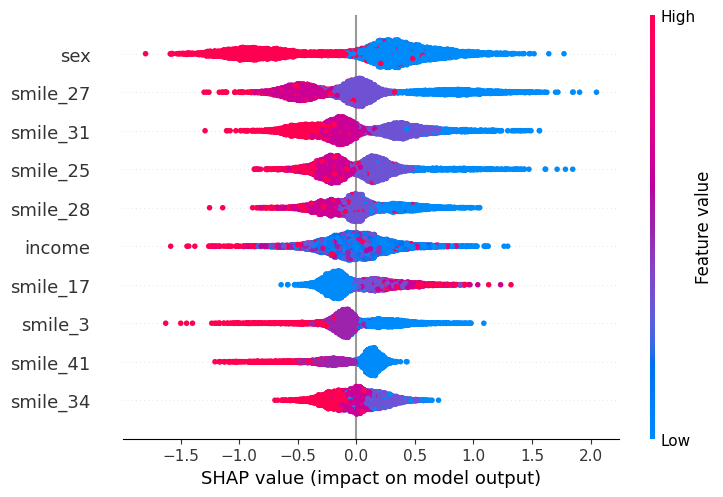

<Figure size 640x480 with 0 Axes>

In [8]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import shap

# Build stacked test set in split order (same order used to append SHAP rows)
X_test_all = pd.concat([split['X_test'] for split in splits], axis=0)

# all_shap_values was filled row-by-row in cell 8
sv = np.asarray(all_shap_values)
if sv.ndim != 2:
    raise ValueError(f"Expected 2D SHAP matrix, got shape {sv.shape}")
if sv.shape[0] != X_test_all.shape[0]:
    raise ValueError(
        f"Row mismatch: SHAP rows={sv.shape[0]} vs X_test rows={X_test_all.shape[0]}"
    )

sv_df = pd.DataFrame(sv, columns=X_test_all.columns, index=X_test_all.index)

# Aggregate one-hot encoded features to their original variable names
sv_agg = sv_df.T.groupby(one_hot_agg).sum().T

X_agg = pd.DataFrame(index=X_test_all.index)
for feat in sv_agg.columns:
    cols = [c for c in X_test_all.columns if one_hot_agg(c) == feat]

    if len(cols) == 1:
        X_agg[feat] = X_test_all[cols[0]]
    elif feat in one_hotted:
        X_agg[feat] = X_test_all[cols].to_numpy().argmax(axis=1)
    else:
        X_agg[feat] = X_test_all[cols].mean(axis=1)

expl = shap.Explanation(
    values=sv_agg.values,
    data=X_agg[sv_agg.columns].values,
    feature_names=list(sv_agg.columns),
)

plt.figure(figsize=(10, 8))
shap.plots.beeswarm(expl, max_display=10, group_remaining_features=False)
plt.tight_layout()
plt.show()

In [10]:
import os
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import shap

os.makedirs("regions_shap", exist_ok=True)

one_hotted = ["sex", "gender_identity", "sexual_orientation", "ethnic_group", 
              "marital_status", "student_accommodation", "work", "course", "bmi_class"]

smile_variable_groups = {
    "score_food_smile": [
        "smile_2", "smile_3", "smile_5"
    ],
    "score_subs_smile": [
        "smile_8", "smile_9", "smile_10", "smile_11"
    ],
    "score_PA_smile": [
        "smile_12", "smile_13", "smile_15"
    ],
    "score_stress_smile": [
        "smile_17", "smile_19"
    ],
    "score_sleep_smile": [
        "smile_25", "smile_27", "smile_28", "smile_41"
    ],
    "score_social_smile": [
        "smile_30", "smile_31", "smile_32", "smile_34", "smile_37"
    ],
    "score_envir_smile": [
        "smile_40", "smile_42", "smile_43"
    ]
}

feature_to_group_map = {}
for group_name, features in smile_variable_groups.items():
    for feature in features:
        feature_to_group_map[feature] = group_name

def aggregate_features(feature_name):
    if feature_name in feature_to_group_map:
        return feature_to_group_map[feature_name]

    for prefix in one_hotted:
        if feature_name.startswith(prefix):
            return prefix

    return feature_name

all_shap_list = []
all_X_test_list = []
all_shap_array = np.asarray(all_shap_values)
cursor = 0

for i, split in enumerate(splits):
    X_test = split['X_test'].copy()
    n_rows = len(X_test)
    shap_vals = all_shap_array[cursor:cursor + n_rows]
    cursor += n_rows

    if isinstance(shap_vals, shap.Explanation):
        shap_array = shap_vals.values
    elif isinstance(shap_vals, list):
        shap_array = shap_vals[1] if len(shap_vals) > 1 else shap_vals[0]
    elif isinstance(shap_vals, pd.DataFrame):
        shap_array = shap_vals.values
    else:
        shap_array = np.asarray(shap_vals)
        if shap_array.ndim == 3:
            shap_array = shap_array[:, :, 1]

    if shap_array.ndim == 1:
        shap_array = shap_array.reshape(1, -1)

    shap_df = pd.DataFrame(shap_array, columns=X_test.columns, index=X_test.index)

    all_shap_list.append(shap_df)
    all_X_test_list.append(X_test)

shap_df_all = pd.concat(all_shap_list, axis=0, ignore_index=False)
X_test_all = pd.concat(all_X_test_list, axis=0, ignore_index=False)

# ── Per-region SHAP plots ─────────────────────────────────────────────────────
for code, region_name in enumerate(REGION_NAMES):
    region_idx = region_indexes[code]
    region_mask = shap_df_all.index.isin(region_idx)

    shap_df_region = shap_df_all.loc[region_mask]
    X_test_region = X_test_all.loc[region_mask]

    if len(shap_df_region) == 0:
        print(f"[{region_name}] No test samples — skipping.")
        continue

    print(f"\n── Region: {region_name} (n={len(shap_df_region)}) ──")

    shap_df_agg = shap_df_region.T.groupby(aggregate_features).sum().T

    X_test_agg_list = []
    for col_group in shap_df_agg.columns:
        group_cols = [c for c in X_test_region.columns if aggregate_features(c) == col_group]

        is_onehot = any(col_group == prefix for prefix in one_hotted)

        if len(group_cols) > 1 and is_onehot:
            X_test_agg_list.append(X_test_region[group_cols].values.argmax(axis=1))
        elif len(group_cols) > 1:
            X_test_agg_list.append(X_test_region[group_cols].mean(axis=1).values)
        else:
            X_test_agg_list.append(X_test_region[col_group].values)

    X_test_agg = pd.DataFrame(
        np.column_stack(X_test_agg_list),
        columns=shap_df_agg.columns,
        index=X_test_region.index
    )

    common_columns = [c for c in shap_df_agg.columns if c != 'region']
    shap_df_agg = shap_df_agg[common_columns]
    X_test_agg = X_test_agg[common_columns]

    if 'gender_identity' in X_test_agg.columns:
        X_test_agg['gender_identity'] = X_test_agg.index.isin(gender_dicotomico_indexes).astype(int)

    if 'sexual_orientation' in X_test_agg.columns:
        X_test_agg['sexual_orientation'] = X_test_agg.index.isin(sexual_dicotomico_indexes).astype(int)

    slug = region_name.replace(" ", "_").lower()

    expl = shap.Explanation(
        values=shap_df_agg.values,
        data=X_test_agg.values,
        feature_names=common_columns
    )

    # Beeswarm
    plt.figure(figsize=(10, 8))
    plt.title(f"SHAP Beeswarm — {region_name}", fontsize=14, pad=12)
    shap.plots.beeswarm(expl, max_display=10, group_remaining_features=False, show=False)
    plt.tight_layout()
    plt.savefig(f"regions_shap-old/{slug}_beeswarm.png", dpi=150, bbox_inches="tight")
    plt.close()

    # Bar summary
    plt.figure(figsize=(10, 6))
    plt.title(f"SHAP Bar — {region_name}", fontsize=14, pad=12)
    shap.plots.bar(expl, max_display=30, show=False)
    plt.tight_layout()
    plt.savefig(f"regions_shap-old/{slug}_bar.png", dpi=150, bbox_inches="tight")
    plt.close()


── Region: center-west (n=335) ──

── Region: north (n=257) ──

── Region: northeast (n=2788) ──

── Region: south (n=918) ──

── Region: southeast (n=1412) ──


In [30]:
import os
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import shap

os.makedirs("courses_shap", exist_ok=True)

COURSE_NAMES = {
    0: "Ciências Exatas e da Terra",
    1: "Engenharias",
    2: "Ciências Biológicas",
    3: "Ciências da Saúde",
    4: "Ciências Agrárias",
    5: "Ciências Humanas",
    6: "Ciências Sociais Aplicadas",
    7: "Linguística, Letras e Artes",
}

COURSE_SLUGS = {
    0: "exatas_terra",
    1: "engenharias",
    2: "biologicas",
    3: "saude",
    4: "agrarias",
    5: "humanas",
    6: "sociais_aplicadas",
    7: "ling_letras_artes",
}

# Build course indexes (original df indexes per course value)
course_values = sorted(df['course'].dropna().unique().astype(int).tolist())
max_course = max(course_values)

course_indexes = {
    c: df.index[df['course'] == c].tolist()
    for c in course_values
    if c != max_course
}

print(f"Courses to plot (excluding max={max_course}):")
for c, idxs in sorted(course_indexes.items()):
    print(f"  {c} — {COURSE_NAMES.get(c, f'Course {c}')}: {len(idxs)}")

# ── Per-course SHAP plots ─────────────────────────────────────────────────────
for course_val, course_idx in sorted(course_indexes.items()):
    course_mask = shap_df_all.index.isin(course_idx)

    shap_df_course = shap_df_all.loc[course_mask]
    X_test_course = X_test_all.loc[course_mask]

    course_name = COURSE_NAMES.get(course_val, f"Course {course_val}")
    slug = COURSE_SLUGS.get(course_val, f"course_{course_val}")

    if len(shap_df_course) == 0:
        print(f"[{course_name}] No test samples — skipping.")
        continue

    print(f"\n── {course_name} (n={len(shap_df_course)}) ──")

    shap_df_agg = shap_df_course.T.groupby(aggregate_features).sum().T

    X_test_agg_list = []
    for col_group in shap_df_agg.columns:
        group_cols = [c for c in X_test_course.columns if aggregate_features(c) == col_group]

        is_onehot = any(col_group == prefix for prefix in one_hotted)

        if len(group_cols) > 1 and is_onehot:
            X_test_agg_list.append(X_test_course[group_cols].values.argmax(axis=1))
        elif len(group_cols) > 1:
            X_test_agg_list.append(X_test_course[group_cols].mean(axis=1).values)
        else:
            X_test_agg_list.append(X_test_course[col_group].values)

    X_test_agg = pd.DataFrame(
        np.column_stack(X_test_agg_list),
        columns=shap_df_agg.columns,
        index=X_test_course.index
    )

    common_columns = [c for c in shap_df_agg.columns if c != 'course']
    shap_df_agg = shap_df_agg[common_columns]
    X_test_agg = X_test_agg[common_columns]

    if 'gender_identity' in X_test_agg.columns:
        X_test_agg['gender_identity'] = X_test_agg.index.isin(gender_dicotomico_indexes).astype(int)

    if 'sexual_orientation' in X_test_agg.columns:
        X_test_agg['sexual_orientation'] = X_test_agg.index.isin(sexual_dicotomico_indexes).astype(int)

    expl = shap.Explanation(
        values=shap_df_agg.values,
        data=X_test_agg.values,
        feature_names=common_columns
    )

    # Beeswarm
    plt.figure(figsize=(10, 8))
    plt.title(f"SHAP Beeswarm — {course_name}", fontsize=14, pad=12)
    shap.plots.beeswarm(expl, max_display=10, group_remaining_features=False, show=False)
    plt.tight_layout()
    plt.savefig(f"courses_shap/{slug}_beeswarm.png", dpi=150, bbox_inches="tight")
    plt.close()

    # Bar summary
    plt.figure(figsize=(10, 6))
    plt.title(f"SHAP Bar — {course_name}", fontsize=14, pad=12)
    shap.plots.bar(expl, max_display=30, show=False)
    plt.tight_layout()
    plt.savefig(f"courses_shap/{slug}_bar.png", dpi=150, bbox_inches="tight")
    plt.close()


Courses to plot (excluding max=8):
  0 — Ciências Exatas e da Terra: 1042
  1 — Engenharias: 785
  2 — Ciências Biológicas: 361
  3 — Ciências da Saúde: 1577
  4 — Ciências Agrárias: 258
  5 — Ciências Humanas: 845
  6 — Ciências Sociais Aplicadas: 1048
  7 — Linguística, Letras e Artes: 458

── Ciências Exatas e da Terra (n=969) ──

── Engenharias (n=688) ──

── Ciências Biológicas (n=314) ──

── Ciências da Saúde (n=1414) ──

── Ciências Agrárias (n=231) ──

── Ciências Humanas (n=724) ──

── Ciências Sociais Aplicadas (n=938) ──

── Linguística, Letras e Artes (n=413) ──
